In [1]:
list.of.packages <- c("tidyverse","fixest","stargazer","ggfixest","patchwork","data.table","broom")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 



Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


Les objet

In [2]:
T_bins_labels <- c("<=17°C","17,21]","21,23]","23,25]","25,27]","27,29]","29,31]","31,33]",">33°C")
T_bins_labels_pretty <- c("≤17°C", "(17,21]", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")

WB_bins_labels <- c("<=14°C","14,16]","16,18]","18,20]","20,22]","22,24]","24,26]","26,28]",">28°C")
WB_bins_labels_pretty <- c("≤14°C","(14,16]","(16,18]","(18,20]","(20,22]","(22,24]","(24,26]","(26,28]",">28°C")

bin_ref_T <-"17,21]"
bin_ref_WB <-"16,18]"

# Children

In [3]:
df_children <- fread("./2_Regression_datasets/output/df_reg_children.csv")
sprintf("%i rows x %i columns", nrow(df_children), ncol(df_children))
head(df_children,2)

[1] "281812 rows x 321 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Mother_id,Child_id,Resp_nb,Interview_month,Interview_year,Measured_date_CDC,Measured_date,Measured_day,Measured_month,Measured_year,Birth_month,Birth_year,Child_female,Child_birth_order,Child_alive_age_month,Child_hemo_level_alti,Child_weight_for_height_zscore,Child_diarrhea,Child_fever,Child_cough,Child_still_breastfeeding,Child_given_plain_water,Child_given_juice,Child_given_milk,Child_given_baby_formula,Child_given_fortified_baby_food,Child_given_soup,Child_given_other_liquid,Child_given_chicken_duck_birds,Child_given_bread_noodles_grains,Child_given_potatoes_cassava_tubers,Child_given_eggs,Child_given_pumkins_carrots_squash,Child_given_green_vegetables,Child_given_mangoes_papaya_vitaminAfruits,Child_given_other_fruits,Child_given_liver_heart_organs,Child_given_fish_sellfish,Child_given_beans_peas_lentils_nuts,Child_given_cheese_yogurt_milk_products,Child_given_other_solid_semisolid_food,Child_given_other_meat,Child_given_yogurt,Child_iron_supplem_7d,Mother_no_educ,Mother_prim_educ,Mother_second_educ,Mother_higher_educ,Mother_hindu,Mother_muslim,Mother_not_hindu_nor_muslim,Mother_ethni_SC,Mother_ethni_ST,Mother_ethni_OBC,Mother_ethni_other,Mother_height,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,Interview_cdc,Wasted,Age_rounded,Children_anemia,Child_severe_anemia,Child_moderate_anemia,Child_mild_anemia,Child_no_anemia,Season,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_

In [4]:
df_reg_children <- df_children %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels))

# Women

In [5]:
df_women <- fread("./2_Regression_datasets/output/df_reg_women.csv")
sprintf("%i rows x %i columns", nrow(df_women), ncol(df_women))
head(df_women,2)

[1] "973462 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Women_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Currently_pregnant,Blood_hemo_level_alti,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Body_mass_index,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Women_anemia,Women_severe_anemia,Women_moderate_anemia,Women_mild_anemia,Women_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T

In [6]:
df_reg_women <- df_women %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels))

# Men

In [7]:
df_men <- fread("./2_Regression_datasets/output/df_reg_men.csv")
sprintf("%i rows x %i columns", nrow(df_men), ncol(df_men))
head(df_men,2)

[1] "150101 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Men_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Profession,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Blood_hemo_level_alti,Body_mass_index,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Men_anemia,Men_severe_anemia,Men_moderate_anemia,Men_mild_anemia,Men_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T_MaxBin_27_29_Ndays_

In [8]:
df_reg_men <- df_men %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels),
                       WB_i30_bin=factor(gsub("\\(","",WB_i30_bin),levels=WB_bins_labels)
)

# Age heterogeneity Children

In [9]:
reg_child_age_T <- feols(Child_hemo_level_alti ~ Age_rounded + i(T_i30_bin,Age_rounded,ref=bin_ref_T) + P_tot_30 + 
                                        Child_female + Child_birth_order +
                                        #Child_alive_age_month + 
                                        Mother_prim_educ + Mother_second_educ + Mother_higher_educ +
                                        Mother_muslim + Mother_not_hindu_nor_muslim  + 
                                        Mother_ethni_SC + Mother_ethni_ST + Mother_ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                        vcov = ~District_ID,
                        df_reg_children%>%mutate(Age_rounded=factor(Age_rounded)))

NOTES: 16,652 observations removed because of NA values (RHS: 16,652).
       38/7 fixed-effect singletons were removed (38 observations).



In [10]:
age_list <- c(":6",":12",":18",":24",":30",":36",":42",":48",":54",":59")

In [11]:
extract_estimate <- function(df,group_name,age_name,Tbin_name){
            row <- tidy(df,conf.int=TRUE)%>%
                         filter(grepl(Tbin_name,term)&grepl(age_name,term))%>% 
                         mutate(age = age_name, 
                                group = group_name,
                                Tbin = Tbin_name)
            return(row)
}

In [12]:
children_estimates <- data.frame()
for (age_name in age_list){
    for (Tbin_name in T_bins_labels){
        row_estimate <- extract_estimate(reg_child_age_T,"Children",age_name,Tbin_name)
        children_estimates <- rbind(children_estimates,row_estimate)
        }
    }

In [13]:
all_estimates <- children_estimates %>%
                   mutate(Tbin=factor(Tbin,levels=T_bins_labels),
                          age=sub(":","",age),
                          age=factor(age,levels=c("6","12","18","24","30","36","42","48","54","59")))
all_estimates

term,estimate,std.error,statistic,p.value,conf.low,conf.high,age,group,Tbin
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<fct>
T_i30_bin::<=17°C:Age_rounded::6,0.99579954,1.1532511,0.86347158,3.882022e-01,-1.2688205,3.26041956,6,Children,<=17°C
"T_i30_bin::21,23]:Age_rounded::6",1.80087791,1.1167247,1.61264263,1.073159e-01,-0.3920159,3.99377170,6,Children,"21,23]"
"T_i30_bin::23,25]:Age_rounded::6",1.19031072,1.1390460,1.04500674,2.964150e-01,-1.0464149,3.42703637,6,Children,"23,25]"
"T_i30_bin::25,27]:Age_rounded::6",1.39463096,0.9820708,1.42009205,1.560686e-01,-0.5338452,3.32310711,6,Children,"25,27]"
"T_i30_bin::27,29]:Age_rounded::6",-1.19963672,1.0054744,-1.19310518,2.332710e-01,-3.1740701,0.77479666,6,Children,"27,29]"
"T_i30_bin::29,31]:Age_rounded::6",-0.81798412,1.2380798,-0.66068770,5.090507e-01,-3.2491809,1.61321269,6,Children,"29,31]"
"T_i30_bin::31,33]:Age_rounded::6",-1.63528403,1.4815758,-1.10374644,2.701186e-01,-4.5446298,1.27406177,6,Children,"31,33]"
T_i30_bin::>33°C:Age_rounded::6,-1.27166125,1.6578489,-0.76705500,4.433321e-01,-4.5271515,1.98382900,6,Children,>33°C
T_i30_bin::<=17°C:Age_rounded::12,0.11262621,0.5603073,0.20100792,8.407563e-01,-0.9876399,1.21289234,12,Children,<=17°C


In [14]:
theme_perso <- function(...){
              theme(plot.title = element_text(size = 30, face="bold",hjust=0.5),
                    plot.subtitle = element_text(size = 28),
                    legend.position="top",
                    legend.title = element_text(size = 28,face ="bold"),
                    legend.text = element_text(size = 28),
                    strip.text.x = element_text(size = 28),
                    axis.text.x = element_text(size = 18,angle=45,hjust=1),
                    axis.text.y = element_text(size = 18),
                    axis.title.x = element_text(size = 20, hjust = 0.5),
                    axis.title.y = element_text(size = 20, hjust = 0.5))
}

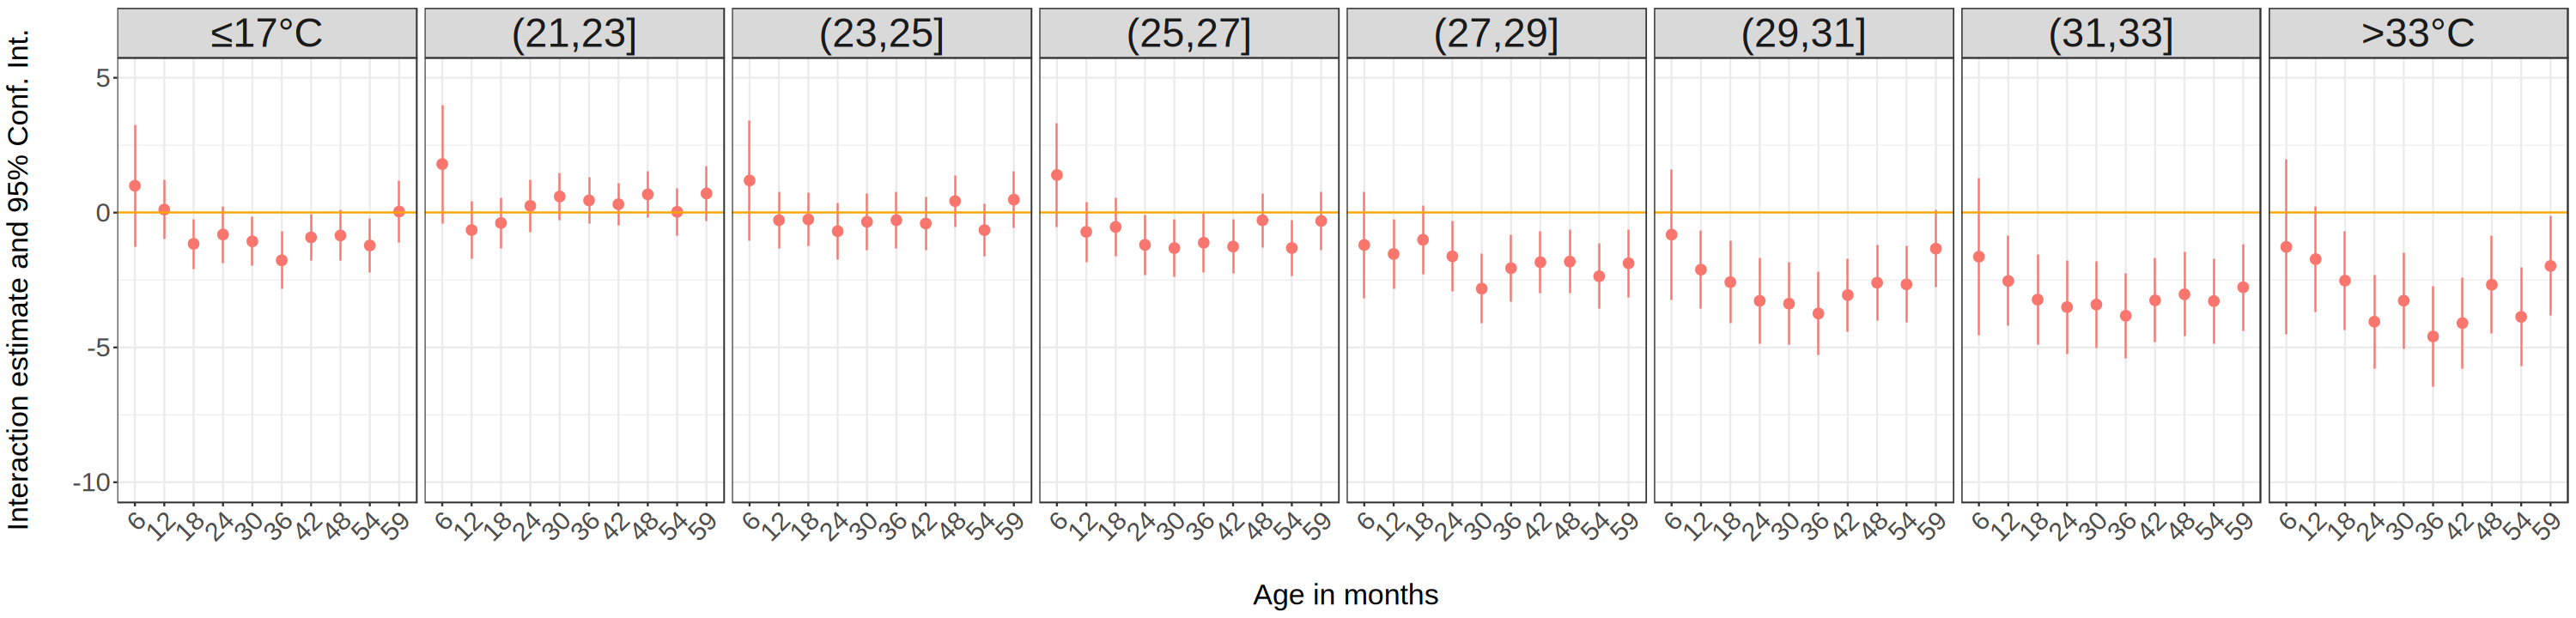

In [15]:
options(repr.plot.width=25, repr.plot.height=6, scipen=9999)

plot_estimates <- ggplot(all_estimates,aes(x=age, y=estimate, ymin=conf.low, ymax=conf.high, color = group)) +
                          geom_pointrange(position = position_dodge(width = 1/4)) +
                          geom_hline(yintercept = 0, col = "orange") +
                          labs(#title ="Hemoglobin level (g/L) - Interaction age and air temperature bin \n",
                               x="\n Age in months", 
                               y="Interaction estimate and 95% Conf. Int.\n", 
                               color="Group")+
                          coord_cartesian(y=c(-10,5))+
                          facet_grid(cols = vars(Tbin),
                                     labeller=as_labeller(setNames(T_bins_labels_pretty,T_bins_labels)))+
                          theme_bw() +
                          theme_perso()+
                          theme(legend.position="none")
plot_estimates

In [16]:
ggsave("./3_output/img/hetero_children_age_hemo.png", width=25, height=6.5, plot_estimates)

# Age heterogeneity Adults

In [17]:
df_reg_women%>%group_by(Age_group)%>%summarize(N=n())

Age_group,N
<chr>,<int>
15-19,166261
20-24,160179
25-29,158289
30-34,137363
35-39,131617
40-44,110950
45-49,108803


In [18]:
df_reg_men%>%group_by(Age_group)%>%summarize(N=n())

Age_group,N
<chr>,<int>
15-19,24714
20-24,21378
25-29,21232
30-34,19663
35-39,19131
40-44,16316
45-49,15637
50-54,12030


In [19]:
reg_women_age_T <- feols(Blood_hemo_level_alti ~  Age_group + i(T_i30_bin,Age_group,ref=bin_ref_T) + P_tot_30 + 
                                        #Current_age + 
                                        N_year_educ + 
                                        Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                        vcov = ~District_ID,
                        df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [20]:
reg_men_age_T <- feols(Blood_hemo_level_alti ~  Age_group + i(T_i30_bin,Age_group,ref=bin_ref_T) + P_tot_30 + 
                                        #Current_age + 
                                        N_year_educ + 
                                        Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                        vcov = ~District_ID,
                        df_reg_men)

NOTES: 9,536 observations removed because of NA values (RHS: 9,536).
       13/1 fixed-effect singletons were removed (13 observations).



In [21]:
age_list_adults <- c("15-19","20-24","25-29","30-34","35-39","40-44","45-49","50-54")

In [22]:
extract_estimate <- function(df,group_name,age_name,Tbin_name){
            row <- tidy(df,conf.int=TRUE)%>%
                         filter(grepl(Tbin_name,term)&grepl(age_name,term))%>% 
                         mutate(age = age_name, 
                                group = group_name,
                                Tbin = Tbin_name)
            return(row)
}

In [23]:
women_estimates <- data.frame()
for (age_name in age_list_adults){
    for (Tbin_name in T_bins_labels){
        row_estimate <- extract_estimate(reg_women_age_T,"Women",age_name,Tbin_name)
        women_estimates <- rbind(women_estimates,row_estimate)
        }
    }

In [24]:
men_estimates <- data.frame()
for (age_name in age_list_adults){
    for (Tbin_name in T_bins_labels){
        row_estimate <- extract_estimate(reg_men_age_T,"Men",age_name,Tbin_name)
        men_estimates <- rbind(men_estimates,row_estimate)
        }
    }

In [25]:
adults_estimates <- rbind(women_estimates,men_estimates) %>%
                   mutate(Tbin=factor(Tbin,levels=T_bins_labels))
adults_estimates

term,estimate,std.error,statistic,p.value,conf.low,conf.high,age,group,Tbin
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<fct>
T_i30_bin::<=17°C:Age_group::15-19,-0.63708027,0.3844963,-1.65692192,0.09802613389986074288,-1.3921092,0.11794863,15-19,Women,<=17°C
"T_i30_bin::21,23]:Age_group::15-19",-0.09676284,0.2875936,-0.33645693,0.73663678740030658076,-0.6615055,0.46797983,15-19,Women,"21,23]"
"T_i30_bin::23,25]:Age_group::15-19",-1.42239317,0.4075129,-3.49042458,0.00051544193113794328,-2.2226195,-0.62216679,15-19,Women,"23,25]"
"T_i30_bin::25,27]:Age_group::15-19",-2.64940431,0.4694154,-5.64405071,0.00000002498508370162,-3.5711875,-1.72762109,15-19,Women,"25,27]"
"T_i30_bin::27,29]:Age_group::15-19",-3.31759284,0.5098767,-6.50665760,0.00000000015527908605,-4.3188292,-2.31635652,15-19,Women,"27,29]"
"T_i30_bin::29,31]:Age_group::15-19",-3.81786911,0.5388430,-7.08530871,0.00000000000367695941,-4.8759862,-2.75975203,15-19,Women,"29,31]"
"T_i30_bin::31,33]:Age_group::15-19",-3.59457992,0.5662163,-6.34842127,0.00000000041264233066,-4.7064496,-2.48271028,15-19,Women,"31,33]"
T_i30_bin::>33°C:Age_group::15-19,-3.70784665,0.6611070,-5.60854240,0.00000003039555431828,-5.0060515,-2.40964182,15-19,Women,>33°C
T_i30_bin::<=17°C:Age_group::20-24,-0.60454772,0.3263776,-1.85229559,0.06444436276071800751,-1.2454499,0.03635447,20-24,Women,<=17°C


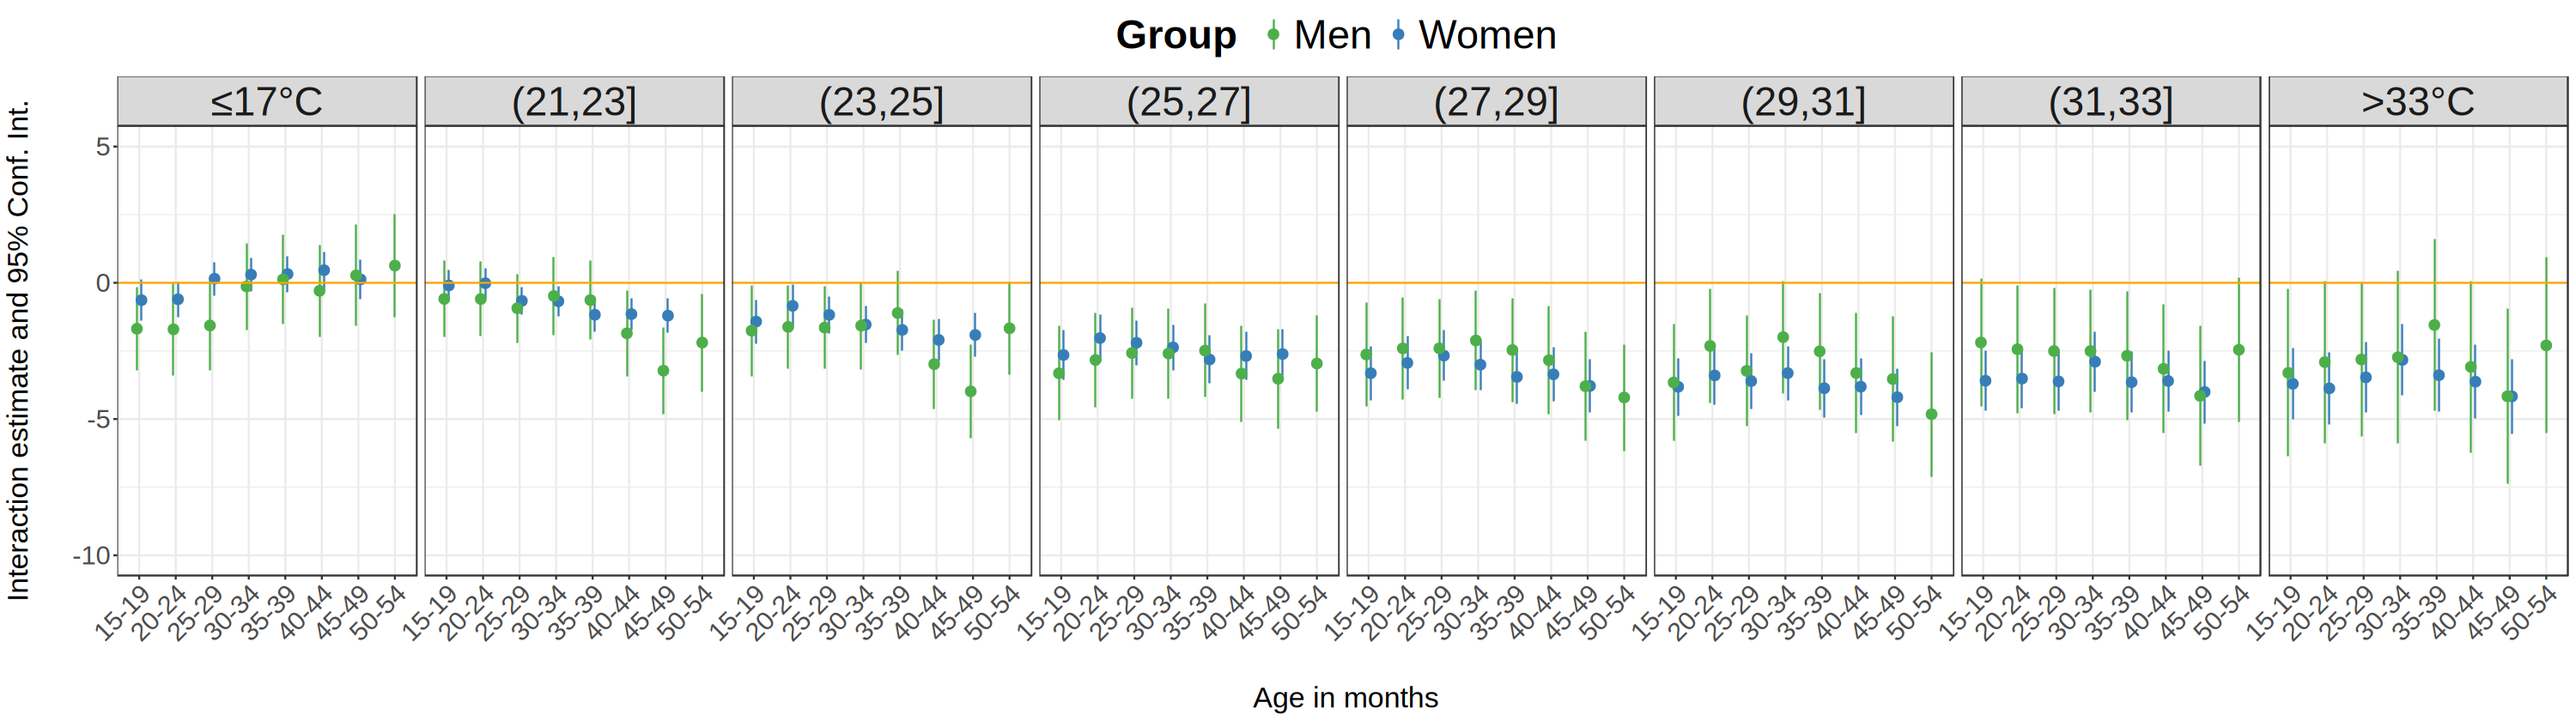

In [26]:
options(repr.plot.width=25, repr.plot.height=7, scipen=9999)

plot_adult_estimates <- ggplot(adults_estimates,aes(x=age, y=estimate, ymin=conf.low, ymax=conf.high, color = group)) +
                          geom_pointrange(position = position_dodge(width = 1/4)) +
                          geom_hline(yintercept = 0, col = "orange") +
                          labs(#title ="Hemoglobin level (g/L) - Interaction age and air temperature bin \n",
                               x="\n Age in months", 
                               y="Interaction estimate and 95% Conf. Int.\n", 
                               color="Group")+
                          scale_color_manual(values = c('#4DAF4A','#377EB8'),#3 of viridis(4),
                                             #labels=c("(1,25(","(25,50(","(50,100(",">100","")
                                             na.value="white")+
                          coord_cartesian(y=c(-10,5))+
                          facet_grid(cols = vars(Tbin),
                                     labeller=as_labeller(setNames(T_bins_labels_pretty,T_bins_labels)))+
                          theme_bw() +
                          theme_perso()
plot_adult_estimates

In [27]:
ggsave("./3_output/img/hetero_adults_age_hemo.png", width=25, height=7, plot_adult_estimates)

# Men excluding 49- 54

In [28]:
df_reg_men_49 <- df_reg_men %>%
                filter(Current_age <= 49)
sprintf("%i rows x %i columns", nrow(df_reg_men_49), ncol(df_reg_men_49))
head(df_reg_men_49,2)

[1] "138071 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Men_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Profession,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Blood_hemo_level_alti,Body_mass_index,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Men_anemia,Men_severe_anemia,Men_moderate_anemia,Men_mild_anemia,Men_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T_MaxBin_27_29_Ndays_

In [29]:
reg_men_T_M1_49 <- feols(Blood_hemo_level_alti ~ i(T_i30_bin,ref=bin_ref_T) + P_tot_30 +
                                        Current_age + N_year_educ + Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                    df_reg_men_49)

NOTES: 8,837 observations removed because of NA values (RHS: 8,837).
       14/1 fixed-effect singletons were removed (14 observations).



In [30]:
nrow(eval(reg_men_T_M1_49$call$data)%>%distinct(District_ID))

[1] 640

In [31]:
reg_men_WBi30_49 <- feols(Blood_hemo_level_alti ~ i(WB_i30_bin,ref=bin_ref_WB) + P_tot_30 +
                                        Current_age + N_year_educ + Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                         |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                    df_reg_men_49)

NOTES: 8,837 observations removed because of NA values (RHS: 8,837).
       14/1 fixed-effect singletons were removed (14 observations).



In [32]:
varT <- "T_i30_bin"
varWB <- "WB_i30_bin"

dict_levels_T <- setNames(paste0("T: ",T_bins_labels_pretty), paste0(varT, "::", T_bins_labels))
dict_levels_WB <- setNames(paste0("WBGT: ",WB_bins_labels_pretty), paste0(varWB, "::", WB_bins_labels))

dict <- c(dict_levels_T, dict_levels_WB)

In [33]:
etable(reg_men_T_M1_49,reg_men_WBi30_49,
       drop="%!_bin",
       dict=dict,
       tex=TRUE,
       fitstat = ~ n + r2 + my)

\begingroup
\centering
\begin{tabular}{lcc}
   \tabularnewline \midrule \midrule
   Dependent Variable: & \multicolumn{2}{c}{Blood\_hemo\_level\_alti}\\
   Model:                         & (1)            & (2)\\  
   \midrule
   \emph{Variables}\\
   T: ≤17°C                       & -0.8561        &   \\   
                                  & (0.5928)       &   \\   
   T: (21,23]                     & -1.174$^{**}$  &   \\   
                                  & (0.4796)       &   \\   
   T: (23,25]                     & -2.294$^{***}$ &   \\   
                                  & (0.6167)       &   \\   
   T: (25,27]                     & -3.178$^{***}$ &   \\   
                                  & (0.7505)       &   \\   
   T: (27,29]                     & -3.052$^{***}$ &   \\   
                                  & (0.8546)       &   \\   
   T: (29,31]                     & -3.399$^{***}$ &   \\   
                                  & (0.9687)       &   \\   
   T: (31,33]       